# Model Development

هذا الدفتر يبني ويقارن ست تجارب تصنيف لاكتشاف فئة الاكتئاب، مع التركيز على أداء الفئة الموجبة (`class 1`).

النماذج المستخدمة:
- Logistic Regression مع `SMOTE`
- Logistic Regression مع `class_weight="balanced"`
- Decision Tree مع `class_weight="balanced"`
- Decision Tree مع `SMOTE`
- Random Forest مع `class_weight="balanced"`
- Random Forest مع `SMOTE`

تسلسل العمل: تحميل البيانات، فحص التوازن، تدريب النماذج، مقارنة النتائج، تفسير أفضل نموذج، حفظ المخرجات، ثم فحص الـ Overfitting.

## 1. Setup

استيراد المكتبات المطلوبة للتعامل مع البيانات، تدريب النماذج، حساب المقاييس، عرض الجداول، ورسم النتائج.

In [94]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
sns.set_theme(style="whitegrid", palette="Set2")


## 2. Load Data and Artifacts

تحميل بيانات التدريب والتحقق والاختبار المعالجة، ونسخة التدريب المتوازنة باستخدام `SMOTE`، بالإضافة إلى عناصر المعالجة وقائمة أسماء الميزات بعد التحويل.

In [95]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = BASE_DIR / "data" / "student_lifestyle_100k.csv"
PREPROCESSING_ARTIFACTS_PATH = BASE_DIR / "data" / "preprocessing_artifacts.pkl"

with open(BASE_DIR / "data" / "preprocessed_original.pkl", "rb") as f:
    X_train_original, X_val_scaled, X_test_scaled, y_train_original, y_val, y_test = pickle.load(f)

with open(BASE_DIR / "notebooks" / "preprocessed_smote.pkl", "rb") as f:
    X_train_smote, _, _, y_train_smote, _, _ = pickle.load(f)

with open(PREPROCESSING_ARTIFACTS_PATH, "rb") as f:
    preprocessing_artifacts = pickle.load(f)

preprocessor = preprocessing_artifacts["preprocessor"]
feature_names = list(preprocessing_artifacts["processed_feature_names"])

print("Number of processed features:", len(feature_names))
feature_names

Number of processed features: 14


['num__Age',
 'num__CGPA',
 'num__Sleep_Duration',
 'num__Study_Hours',
 'num__Social_Media_Hours',
 'num__Physical_Activity',
 'num__Stress_Level',
 'cat__Gender_Female',
 'cat__Gender_Male',
 'cat__Department_Arts',
 'cat__Department_Business',
 'cat__Department_Engineering',
 'cat__Department_Medical',
 'cat__Department_Science']

## 3. Class Distribution

مقارنة توزيع الفئات في بيانات التدريب الأصلية وبعد تطبيق `SMOTE` للتأكد من أثر الموازنة على الفئة الموجبة.

In [96]:
train_distribution_df = pd.concat(
    {
        "original_count": pd.Series(y_train_original).value_counts().sort_index(),
        "original_ratio": pd.Series(y_train_original).value_counts(normalize=True).sort_index(),
        "smote_count": pd.Series(y_train_smote).value_counts().sort_index(),
        "smote_ratio": pd.Series(y_train_smote).value_counts(normalize=True).sort_index(),
    },
    axis=1,
)

train_distribution_df.index.name = "class"
train_distribution_df.round(4)

,original_count,original_ratio,smote_count,smote_ratio
class,,,,
0,71950,0.8994,71950,0.5
1,8050,0.1006,71950,0.5


## 4. Train and Evaluate Models

تعريف دوال التقييم وتشغيل التجارب الست. يتم ترتيب النتائج حسب `test_f1_class_1` ثم `test_recall_class_1` لأن الهدف الأساسي هو تحسين أداء الفئة الموجبة.

In [97]:
def evaluate_predictions(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_class_0": report["0"]["precision"],
        "recall_class_0": report["0"]["recall"],
        "f1_class_0": report["0"]["f1-score"],
        "precision_class_1": report["1"]["precision"],
        "recall_class_1": report["1"]["recall"],
        "f1_class_1": report["1"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "report": report,
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }


def run_experiment(name, model, X_train_used, y_train_used):
    model.fit(X_train_used, y_train_used)

    y_val_pred = model.predict(X_val_scaled)
    y_test_pred = model.predict(X_test_scaled)

    val_metrics = evaluate_predictions(y_val, y_val_pred)
    test_metrics = evaluate_predictions(y_test, y_test_pred)

    return {
        "experiment": name,
        "model_type": type(model).__name__,
        "train_samples": int(len(y_train_used)),
        "train_positive_ratio": float(pd.Series(y_train_used).mean()),
        "val_accuracy": val_metrics["accuracy"],
        "val_precision_class_1": val_metrics["precision_class_1"],
        "val_recall_class_1": val_metrics["recall_class_1"],
        "val_f1_class_1": val_metrics["f1_class_1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision_class_0": test_metrics["precision_class_0"],
        "test_recall_class_0": test_metrics["recall_class_0"],
        "test_f1_class_0": test_metrics["f1_class_0"],
        "test_precision_class_1": test_metrics["precision_class_1"],
        "test_recall_class_1": test_metrics["recall_class_1"],
        "test_f1_class_1": test_metrics["f1_class_1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
        "val_report": val_metrics["report"],
        "test_report": test_metrics["report"],
        "test_confusion_matrix": test_metrics["confusion_matrix"],
        "model": model,
    }


experiments = {
    "logistic_smote": (
        LogisticRegression(random_state=42, max_iter=1000),
        X_train_smote,
        y_train_smote,
    ),
    "logistic_balanced": (
        LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"),
        X_train_original,
        y_train_original,
    ),
    "decision_tree_balanced": (
        DecisionTreeClassifier(
            random_state=42,
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
        ),
        X_train_original,
        y_train_original,
    ),
    "decision_tree_smote": (
        DecisionTreeClassifier(
            random_state=42,
            max_depth=8,
            min_samples_leaf=20,
        ),
        X_train_smote,
        y_train_smote,
    ),
    "random_forest_balanced": (
        RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
        ),
        X_train_original,
        y_train_original,
    ),
    "random_forest_smote": (
        RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            max_depth=12,
            min_samples_leaf=5,
            n_jobs=-1,
        ),
        X_train_smote,
        y_train_smote,
    ),
}

trained_models = {}
results = []

for name, (model, X_train_used, y_train_used) in experiments.items():
    result = run_experiment(name, model, X_train_used, y_train_used)
    trained_models[name] = result.pop("model")
    results.append(result)

results_df = (
    pd.DataFrame(results)
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
)

results_df[
    ["experiment", "model_type", "test_accuracy", "test_recall_class_1", "test_f1_class_1"]
].round(4)

,experiment,model_type,test_accuracy,test_recall_class_1,test_f1_class_1
0,random_forest_balanced,RandomForestClassifier,0.7382,0.5835,0.3096
1,decision_tree_balanced,DecisionTreeClassifier,0.7291,0.6014,0.3088
2,random_forest_smote,RandomForestClassifier,0.7553,0.5149,0.2974
3,decision_tree_smote,DecisionTreeClassifier,0.7529,0.5199,0.2974
4,logistic_smote,LogisticRegression,0.6176,0.6431,0.2528
5,logistic_balanced,LogisticRegression,0.6160,0.6441,0.2523


## 5. Summary Comparison

جدول مختصر للمقارنة السريعة بين النماذج، مع إبراز دقة الاختبار و`Precision` و`Recall` و`F1` للفئة الموجبة.

In [98]:
summary_columns = [
    "experiment",
    "model_type",
    "train_positive_ratio",
    "test_accuracy",
    "test_precision_class_1",
    "test_recall_class_1",
    "test_f1_class_1",
    "test_macro_f1",
    "test_weighted_f1",
]

summary_df = (
    results_df[summary_columns]
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

summary_df

,experiment,model_type,train_positive_ratio,test_accuracy,test_precision_class_1,test_recall_class_1,test_f1_class_1,test_macro_f1,test_weighted_f1
0,random_forest_balanced,RandomForestClassifier,0.1006,0.7382,0.2107,0.5835,0.3096,0.5740,0.7853
1,decision_tree_balanced,DecisionTreeClassifier,0.1006,0.7291,0.2077,0.6014,0.3088,0.5701,0.7789
2,random_forest_smote,RandomForestClassifier,0.5000,0.7553,0.2091,0.5149,0.2974,0.5746,0.7961
3,decision_tree_smote,DecisionTreeClassifier,0.5000,0.7529,0.2083,0.5199,0.2974,0.5738,0.7945
4,logistic_smote,LogisticRegression,0.5000,0.6176,0.1573,0.6431,0.2528,0.4979,0.6937
5,logistic_balanced,LogisticRegression,0.1006,0.6160,0.1569,0.6441,0.2523,0.4970,0.6924


## 6. Detailed Comparison

جدول تفصيلي يحتوي على مقاييس التحقق والاختبار وعناصر مصفوفة الالتباس لكل تجربة.

In [99]:
detailed_columns = [
    "experiment",
    "model_type",
    "train_samples",
    "train_positive_ratio",
    "val_accuracy",
    "val_precision_class_1",
    "val_recall_class_1",
    "val_f1_class_1",
    "test_accuracy",
    "test_precision_class_0",
    "test_recall_class_0",
    "test_f1_class_0",
    "test_precision_class_1",
    "test_recall_class_1",
    "test_f1_class_1",
    "test_macro_f1",
    "test_weighted_f1",
    "tn",
    "fp",
    "fn",
    "tp",
]

detailed_df = (
    results_df[detailed_columns]
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

detailed_df

,experiment,model_type,train_samples,train_positive_ratio,val_accuracy,val_precision_class_1,val_recall_class_1,val_f1_class_1,test_accuracy,test_precision_class_0,...,test_f1_class_0,test_precision_class_1,test_recall_class_1,test_f1_class_1,test_macro_f1,test_weighted_f1,tn,fp,fn,tp
0,random_forest_balanced,RandomForestClassifier,80000,0.1006,0.7431,0.2226,0.6233,0.3280,0.7382,0.9419,...,0.8385,0.2107,0.5835,0.3096,0.5740,0.7853,6795,2199,419,587
1,decision_tree_balanced,DecisionTreeClassifier,80000,0.1006,0.7345,0.2208,0.6481,0.3294,0.7291,0.9434,...,0.8315,0.2077,0.6014,0.3088,0.5701,0.7789,6686,2308,401,605
2,random_forest_smote,RandomForestClassifier,143900,0.5000,0.7599,0.2222,0.5547,0.3173,0.7553,0.9351,...,0.8518,0.2091,0.5149,0.2974,0.5746,0.7961,7035,1959,488,518
3,decision_tree_smote,DecisionTreeClassifier,143900,0.5000,0.7584,0.2220,0.5596,0.3179,0.7529,0.9355,...,0.8501,0.2083,0.5199,0.2974,0.5738,0.7945,7006,1988,483,523
4,logistic_smote,LogisticRegression,143900,0.5000,0.6220,0.1669,0.6909,0.2689,0.6176,0.9390,...,0.7430,0.1573,0.6431,0.2528,0.4979,0.6937,5529,3465,359,647
5,logistic_balanced,LogisticRegression,80000,0.1006,0.6208,0.1666,0.6918,0.2685,0.6160,0.9390,...,0.7417,0.1569,0.6441,0.2523,0.4970,0.6924,5512,3482,358,648


## 7. Best-Model Report

تقرير مركز للنموذج الأفضل حسب ترتيب المقارنة، بدل عرض تقرير كامل لكل تجربة.

In [100]:
focus_model_name = summary_df.iloc[0]["experiment"]
focus_row = results_df.loc[results_df["experiment"] == focus_model_name].iloc[0]

focus_test_report_df = (
    pd.DataFrame(focus_row["test_report"])
    .T
    .loc[["0", "1", "accuracy", "macro avg", "weighted avg"]]
    .round(4)
)

focus_confusion_df = pd.DataFrame(
    focus_row["test_confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

focus_summary_df = pd.DataFrame(
    [
        focus_row[
            [
                "experiment",
                "model_type",
                "test_accuracy",
                "test_recall_class_1",
                "test_f1_class_1",
            ]
        ]
    ]
).round(4)

display(focus_summary_df)
display(focus_test_report_df)
focus_confusion_df

,experiment,model_type,test_accuracy,test_recall_class_1,test_f1_class_1
0,random_forest_balanced,RandomForestClassifier,0.7382,0.5835,0.3096


,precision,recall,f1-score,support
0,0.9419,0.7555,0.8385,8994.0000
1,0.2107,0.5835,0.3096,1006.0000
accuracy,0.7382,0.7382,0.7382,0.7382
macro avg,0.5763,0.6695,0.5740,10000.0000
weighted avg,0.8684,0.7382,0.7853,10000.0000


,Predicted 0,Predicted 1
Actual 0,6795,2199
Actual 1,419,587


## 8. Feature Importance

استخراج أهمية الميزات من النموذج الأفضل. تستخدم النماذج الشجرية `feature_importances_`، ويستخدم الانحدار اللوجستي القيمة المطلقة للمعاملات عند الحاجة.

In [101]:
best_model_name = summary_df.iloc[0]["experiment"]
best_model = trained_models[best_model_name]

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importance_values = np.abs(best_model.coef_).ravel()
else:
    raise ValueError(
        f"Model {type(best_model).__name__} does not expose feature importances or coefficients."
    )

if len(importance_values) != len(feature_names):
    raise ValueError(
        f"Feature importance length ({len(importance_values)}) does not match "
        f"processed feature names length ({len(feature_names)})."
    )

feature_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importance_values,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df

,feature,importance
0,num__CGPA,0.511330
1,num__Stress_Level,0.102692
2,num__Sleep_Duration,0.101915
3,num__Physical_Activity,0.072821
4,num__Study_Hours,0.071869
5,num__Social_Media_Hours,0.068415
6,num__Age,0.030326
7,cat__Gender_Male,0.006368
8,cat__Gender_Female,0.006077
9,cat__Department_Business,0.005911


## 9. Save Models and Results

حفظ أفضل نموذج إجمالًا، وأفضل `Decision Tree`، وأفضل `Random Forest`، بالإضافة إلى ملفات المقارنة وأهمية الميزات وتفاصيل التجارب.

In [102]:
results_dir = BASE_DIR / "results"
models_dir = BASE_DIR / "models"
results_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)

summary_df.to_csv(results_dir / "tree_model_comparison.csv", index=False)
feature_importance_df.to_csv(results_dir / "best_tree_feature_importance.csv", index=False)

decision_tree_best_name = results_df[results_df["model_type"] == "DecisionTreeClassifier"].iloc[0]["experiment"]
random_forest_best_name = results_df[results_df["model_type"] == "RandomForestClassifier"].iloc[0]["experiment"]


def make_prediction_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )


best_pipeline = make_prediction_pipeline(trained_models[best_model_name])
decision_tree_pipeline = make_prediction_pipeline(trained_models[decision_tree_best_name])
random_forest_pipeline = make_prediction_pipeline(trained_models[random_forest_best_name])

with open(models_dir / "saved_tree_best_model.pkl", "wb") as f:
    pickle.dump(trained_models[best_model_name], f)

with open(models_dir / "saved_decision_tree.pkl", "wb") as f:
    pickle.dump(trained_models[decision_tree_best_name], f)

with open(models_dir / "saved_random_forest.pkl", "wb") as f:
    pickle.dump(trained_models[random_forest_best_name], f)

with open(models_dir / "saved_best_model_pipeline.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

with open(models_dir / "saved_decision_tree_pipeline.pkl", "wb") as f:
    pickle.dump(decision_tree_pipeline, f)

with open(models_dir / "saved_random_forest_pipeline.pkl", "wb") as f:
    pickle.dump(random_forest_pipeline, f)

details_payload = {
    "best_experiment": best_model_name,
    "decision_tree_best_experiment": decision_tree_best_name,
    "random_forest_best_experiment": random_forest_best_name,
    "processed_feature_names": feature_names,
    "preprocessing_artifacts_file": "../data/preprocessing_artifacts.pkl",
    "saved_pipeline_files": [
        "../models/saved_best_model_pipeline.pkl",
        "../models/saved_decision_tree_pipeline.pkl",
        "../models/saved_random_forest_pipeline.pkl",
    ],
    "results": results,
}

with open(results_dir / "tree_model_details.json", "w", encoding="utf-8") as f:
    json.dump(details_payload, f, ensure_ascii=False, indent=2)

{
    "best_experiment": best_model_name,
    "decision_tree_best_experiment": decision_tree_best_name,
    "random_forest_best_experiment": random_forest_best_name,
    "saved_files": [
        "../models/saved_tree_best_model.pkl",
        "../models/saved_decision_tree.pkl",
        "../models/saved_random_forest.pkl",
        "../models/saved_best_model_pipeline.pkl",
        "../models/saved_decision_tree_pipeline.pkl",
        "../models/saved_random_forest_pipeline.pkl",
        "../results/tree_model_comparison.csv",
        "../results/best_tree_feature_importance.csv",
        "../results/tree_model_details.json",
    ],
}

{'best_experiment': 'random_forest_balanced',
 'decision_tree_best_experiment': 'decision_tree_balanced',
 'random_forest_best_experiment': 'random_forest_balanced',
 'saved_files': ['../models/saved_tree_best_model.pkl',
  '../models/saved_decision_tree.pkl',
  '../models/saved_random_forest.pkl',
  '../models/saved_best_model_pipeline.pkl',
  '../models/saved_decision_tree_pipeline.pkl',
  '../models/saved_random_forest_pipeline.pkl',
  '../results/tree_model_comparison.csv',
  '../results/best_tree_feature_importance.csv',
  '../results/tree_model_details.json']}

## 10. Visualize Model Performance

رسوم مقارنة لأداء النماذج على الفئة الموجبة من حيث `F1` و`Recall`، ثم مقارنة مشتركة بين `Precision` و`Recall` و`F1`.

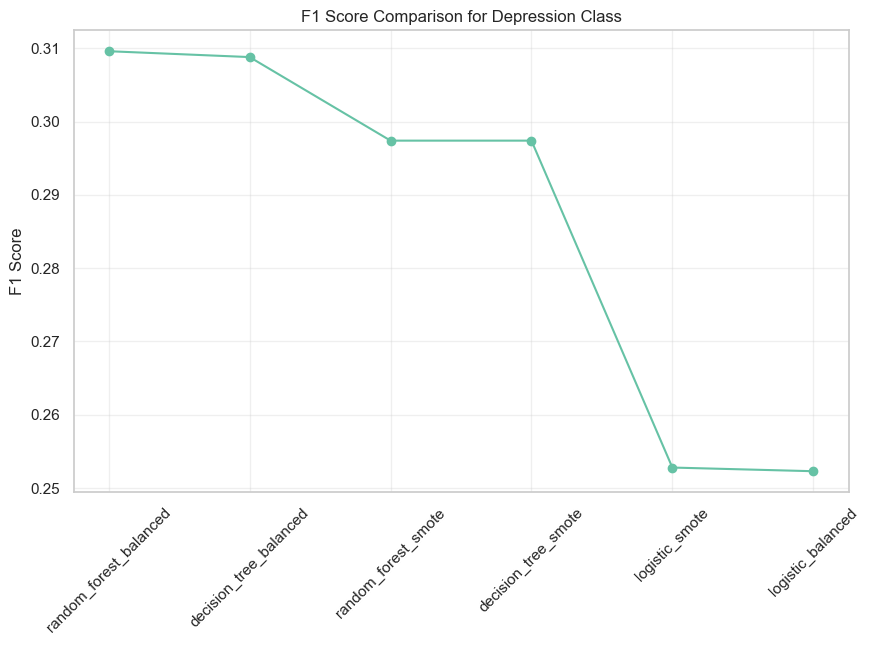

In [103]:
plt.figure(figsize=(10, 6))
plt.plot(summary_df["experiment"], summary_df["test_f1_class_1"], marker="o")

plt.title("F1 Score Comparison for Depression Class")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

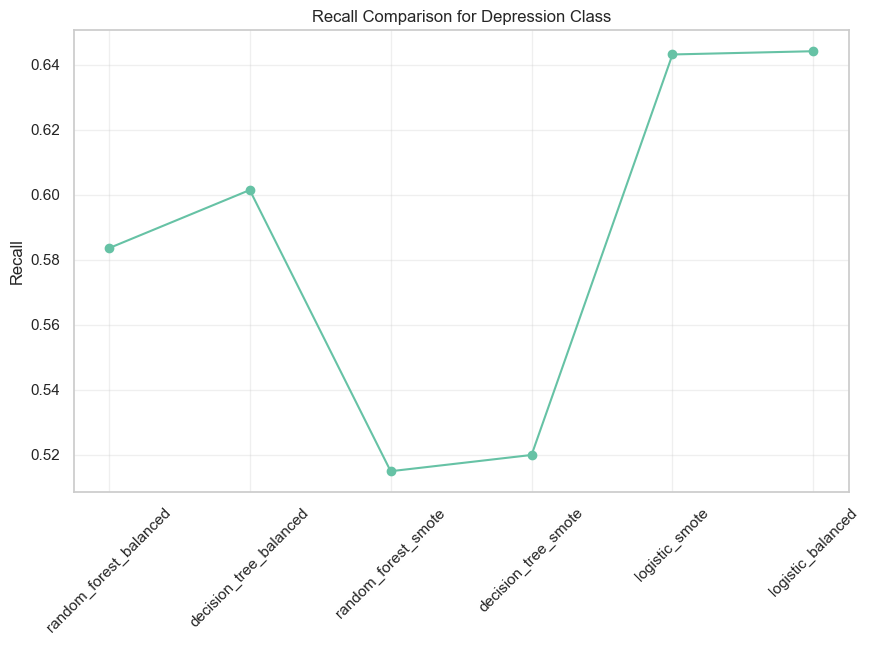

In [104]:
plt.figure(figsize=(10, 6))
plt.plot(summary_df["experiment"], summary_df["test_recall_class_1"], marker="o")

plt.title("Recall Comparison for Depression Class")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

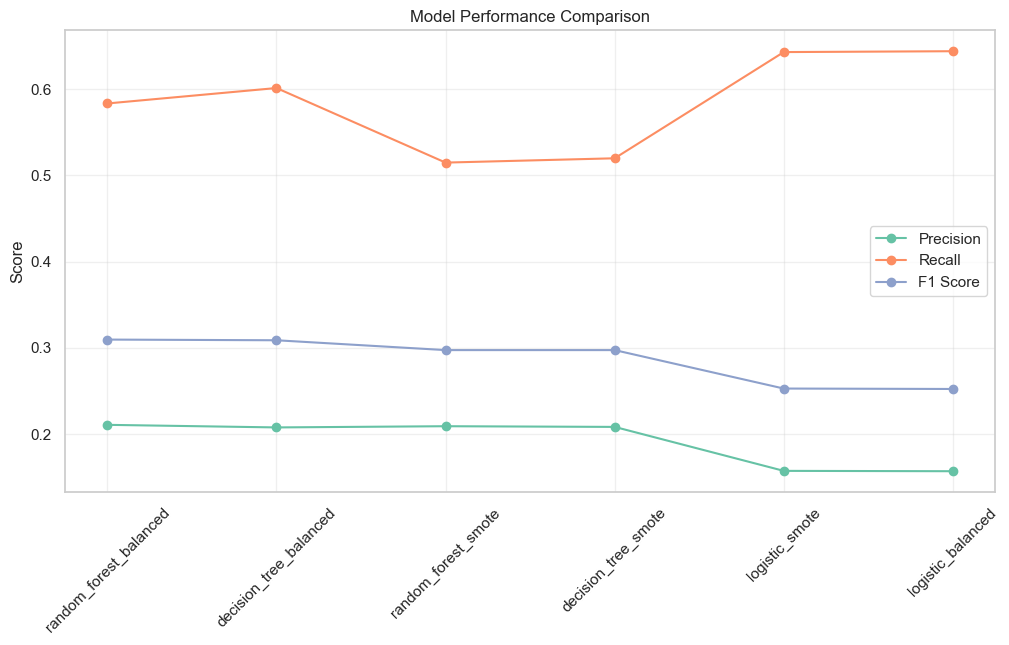

In [105]:
plt.figure(figsize=(12, 6))

plt.plot(
    summary_df["experiment"],
    summary_df["test_precision_class_1"],
    marker="o",
    label="Precision",
)
plt.plot(
    summary_df["experiment"],
    summary_df["test_recall_class_1"],
    marker="o",
    label="Recall",
)
plt.plot(
    summary_df["experiment"],
    summary_df["test_f1_class_1"],
    marker="o",
    label="F1 Score",
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 11. Model Evaluation Graphs

رسوم التقييم النهائية للنماذج داخل هذا الدفتر، بدون الاعتماد على دفتر تقييم منفصل.


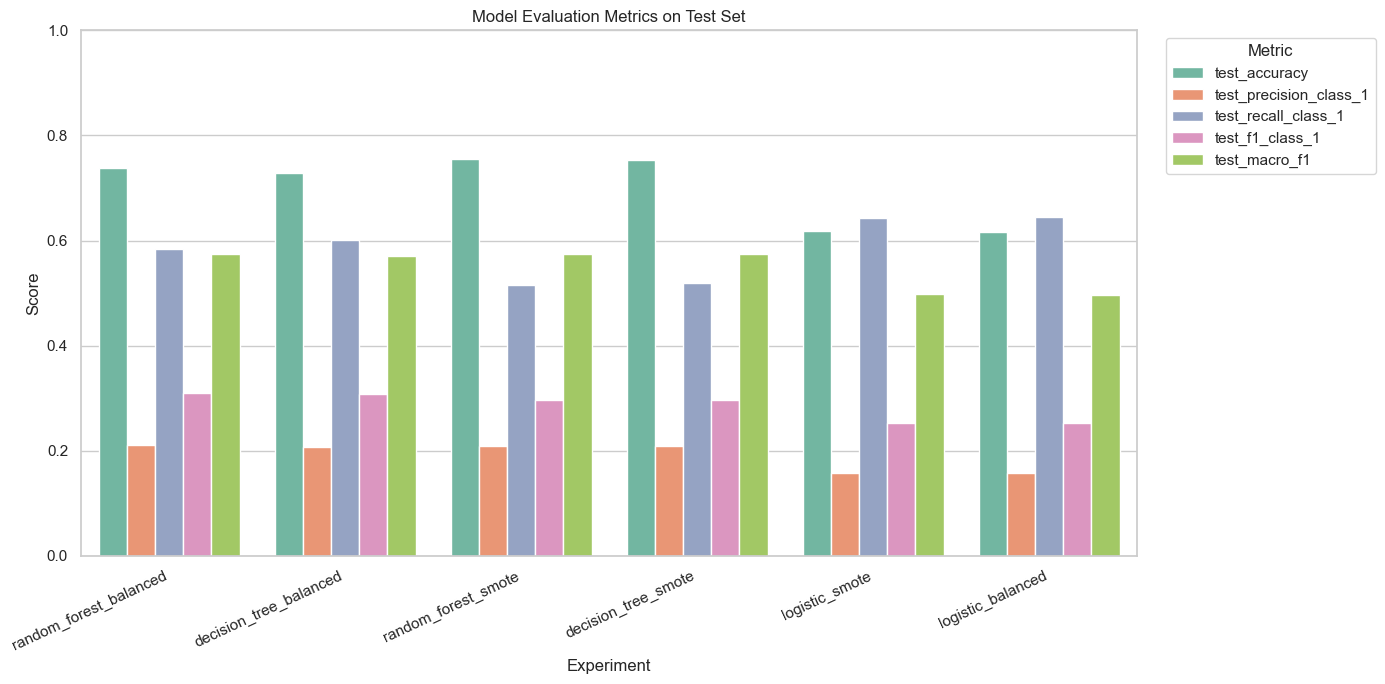

In [106]:
metric_cols = [
    "test_accuracy",
    "test_precision_class_1",
    "test_recall_class_1",
    "test_f1_class_1",
    "test_macro_f1",
]

metrics_long = summary_df.melt(
    id_vars=["experiment", "model_type"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 7))
sns.barplot(data=metrics_long, x="experiment", y="score", hue="metric")
plt.title("Model Evaluation Metrics on Test Set")
plt.xlabel("Experiment")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


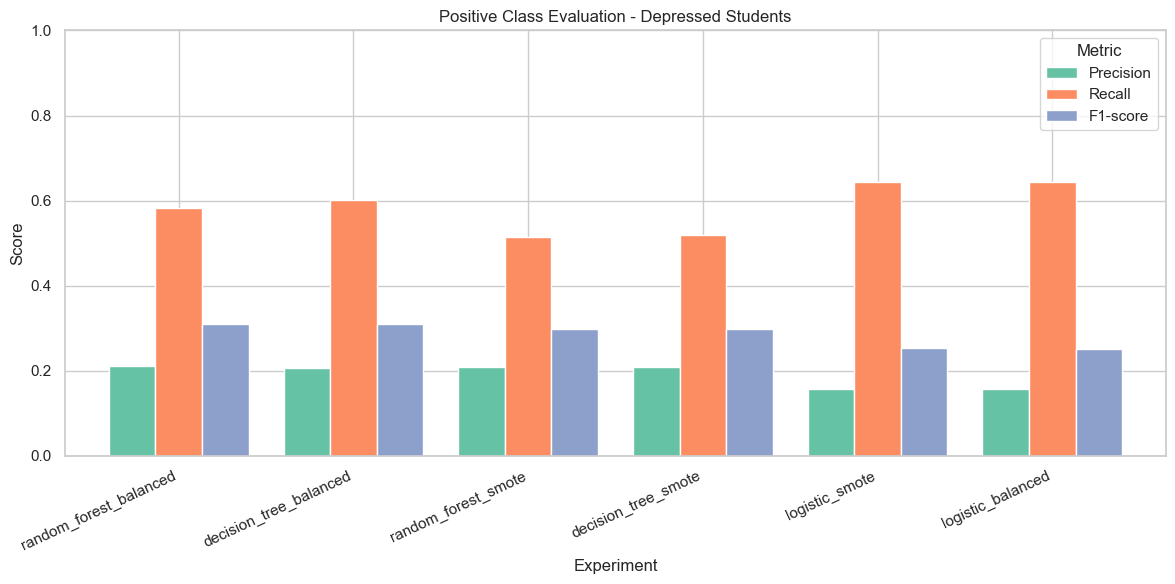

In [107]:
positive_metrics = summary_df[
    ["experiment", "test_precision_class_1", "test_recall_class_1", "test_f1_class_1"]
].set_index("experiment")

ax = positive_metrics.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Positive Class Evaluation - Depressed Students")
ax.set_xlabel("Experiment")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(["Precision", "Recall", "F1-score"], title="Metric")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


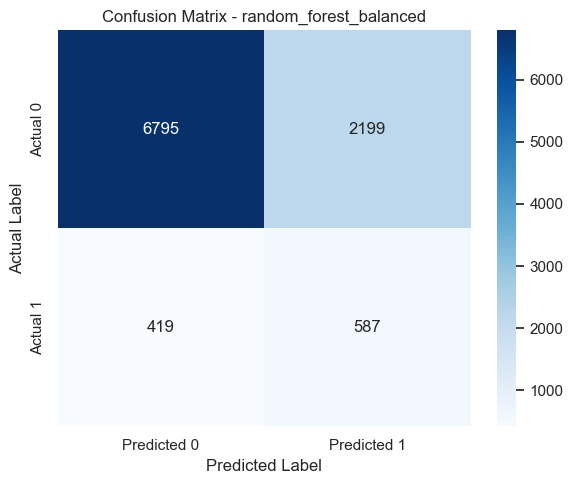

TN=6795, FP=2199, FN=419, TP=587


In [108]:
best_cm = np.array(focus_row["test_confusion_matrix"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"],
)
plt.title(f"Confusion Matrix - {focus_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = focus_row["tn"], focus_row["fp"], focus_row["fn"], focus_row["tp"]
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


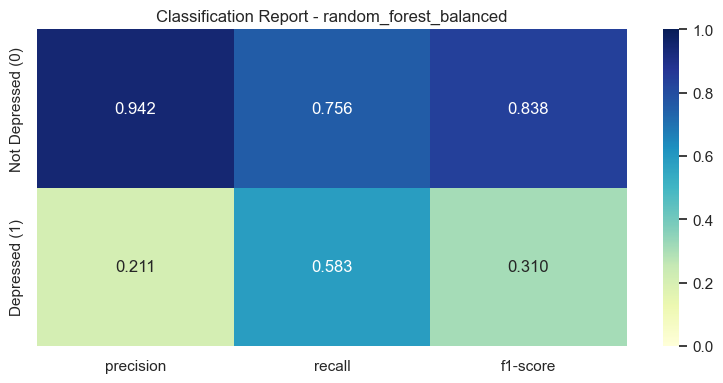

,precision,recall,f1-score
Not Depressed (0),0.941918,0.755504,0.838475
Depressed (1),0.210696,0.583499,0.309599


In [109]:
report_df = pd.DataFrame(focus_row["test_report"]).T
report_metrics = report_df.loc[["0", "1"], ["precision", "recall", "f1-score"]]
report_metrics.index = ["Not Depressed (0)", "Depressed (1)"]

plt.figure(figsize=(8, 4))
sns.heatmap(report_metrics, annot=True, cmap="YlGnBu", fmt=".3f", vmin=0, vmax=1)
plt.title(f"Classification Report - {focus_model_name}")
plt.tight_layout()
plt.show()

display(report_metrics)


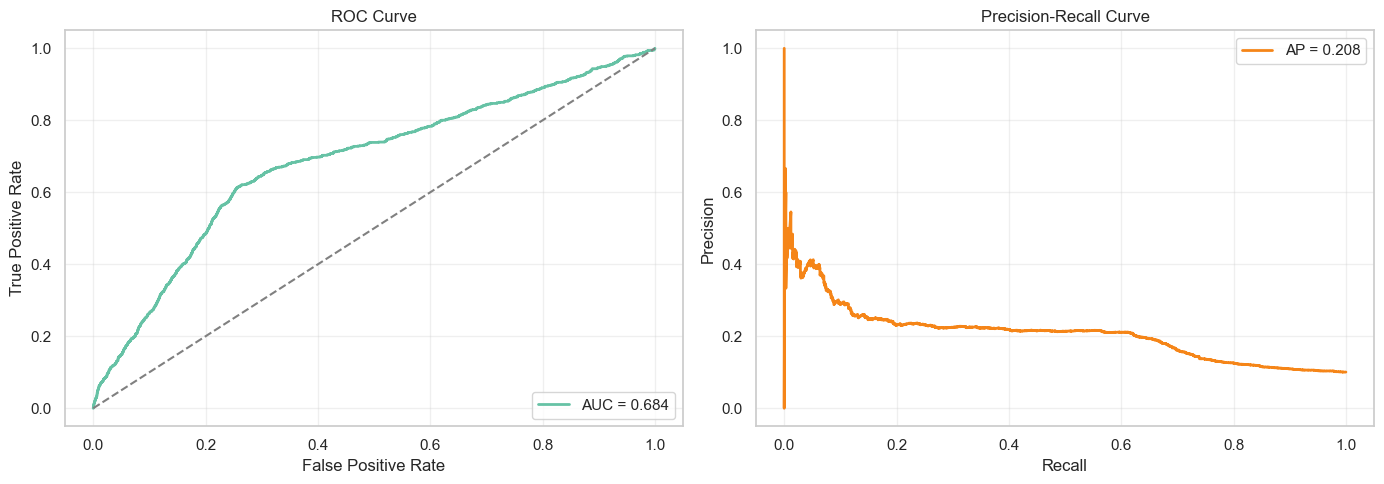

               precision    recall  f1-score   support

Not Depressed       0.94      0.76      0.84      8994
    Depressed       0.21      0.58      0.31      1006

     accuracy                           0.74     10000
    macro avg       0.58      0.67      0.57     10000
 weighted avg       0.87      0.74      0.79     10000



In [110]:
y_test_binary = pd.Series(y_test).astype(int)
y_test_pred = pd.Series(best_model.predict(X_test_scaled)).astype(int)

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_score = best_model.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test_binary, y_score)
avg_precision = average_precision_score(y_test_binary, y_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(recall, precision, label=f"AP = {avg_precision:.3f}", linewidth=2, color="#F58518")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(classification_report(y_test_binary, y_test_pred, target_names=["Not Depressed", "Depressed"]))


## 12. Overfitting Detection

مقارنة أداء النموذج الأفضل على التدريب والتحقق والاختبار، ثم رسم الفجوات لتقييم وجود Overfitting.

In [111]:
best_model_name = summary_df.iloc[0]["experiment"]
best_model = trained_models[best_model_name]

# Compare the selected model on train, validation, and test splits.
y_train_pred = best_model.predict(X_train_original)
y_val_pred = best_model.predict(X_val_scaled)
y_test_pred = best_model.predict(X_test_scaled)

train_acc = accuracy_score(y_train_original, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_val_gap = train_acc - val_acc
train_test_gap = train_acc - test_acc

overfitting_df = pd.DataFrame(
    {
        "Dataset": ["Training", "Validation", "Test"],
        "Accuracy": [train_acc, val_acc, test_acc],
        "Gap from Train": [0, train_val_gap, train_test_gap],
    }
).round(4)

display(overfitting_df)

print("\n📊 تحليل الـ Overfitting:")
print(f"النموذج الأفضل: {best_model_name}\n")

if train_test_gap < 0.05:
    print("✅ لا يوجد overfitting واضح - النموذج متوازن")
elif train_test_gap < 0.10:
    print("⚠️  overfitting طفيف - النموذج يعمل بشكل معقول")
else:
    print("⛔ overfitting واضح - النموذج متفرط على بيانات التدريب")

print(f"\nالفرق بين Train و Test: {train_test_gap:.4f}")
print(f"الفرق بين Train و Val: {train_val_gap:.4f}")

,Dataset,Accuracy,Gap from Train
0,Training,0.7512,0.0000
1,Validation,0.7431,0.0081
2,Test,0.7382,0.0130



📊 تحليل الـ Overfitting:
النموذج الأفضل: random_forest_balanced

✅ لا يوجد overfitting واضح - النموذج متوازن

الفرق بين Train و Test: 0.0130
الفرق بين Train و Val: 0.0081


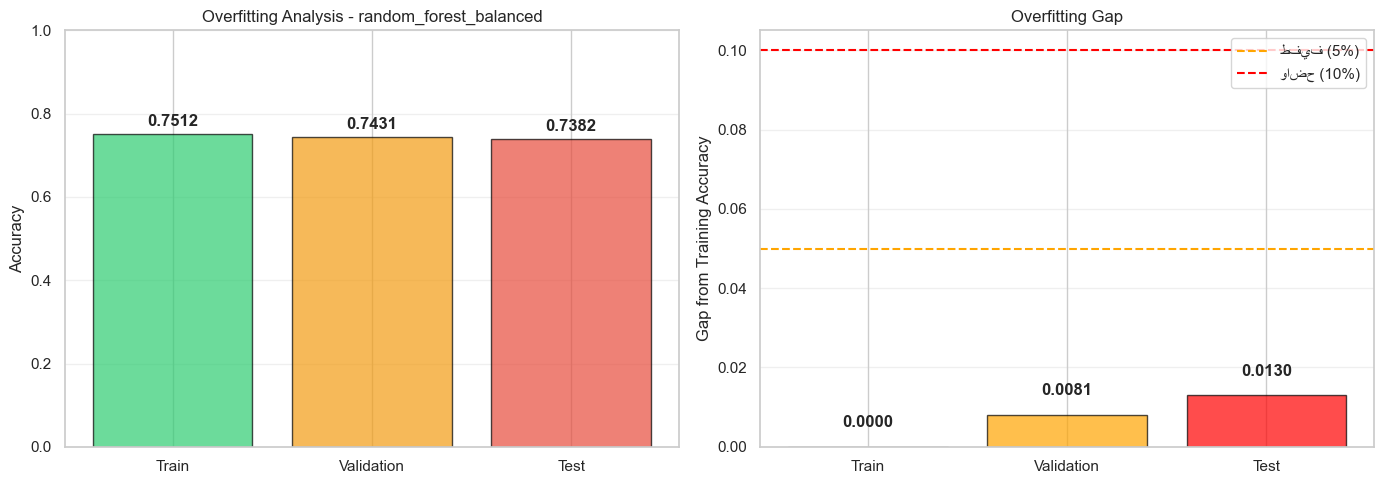

In [112]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

datasets = ["Train", "Validation", "Test"]
accuracies = [train_acc, val_acc, test_acc]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

ax1.bar(datasets, accuracies, color=colors, alpha=0.7, edgecolor="black")
ax1.set_ylabel("Accuracy")
ax1.set_title(f"Overfitting Analysis - {best_model_name}")
ax1.set_ylim([0, 1])
ax1.grid(axis="y", alpha=0.3)

for index, accuracy in enumerate(accuracies):
    ax1.text(index, accuracy + 0.02, f"{accuracy:.4f}", ha="center", fontweight="bold")

gaps = [0, train_val_gap, train_test_gap]
ax2.bar(datasets, gaps, color=["green", "orange", "red"], alpha=0.7, edgecolor="black")
ax2.set_ylabel("Gap from Training Accuracy")
ax2.set_title("Overfitting Gap")
ax2.axhline(y=0.05, color="orange", linestyle="--", label="طفيف (5%)")
ax2.axhline(y=0.10, color="red", linestyle="--", label="واضح (10%)")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

for index, gap in enumerate(gaps):
    ax2.text(index, gap + 0.005, f"{gap:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()